<a href="https://colab.research.google.com/github/liorg/learning-notes/blob/main/ml/loss/loss_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

הסבר של mse vs bse

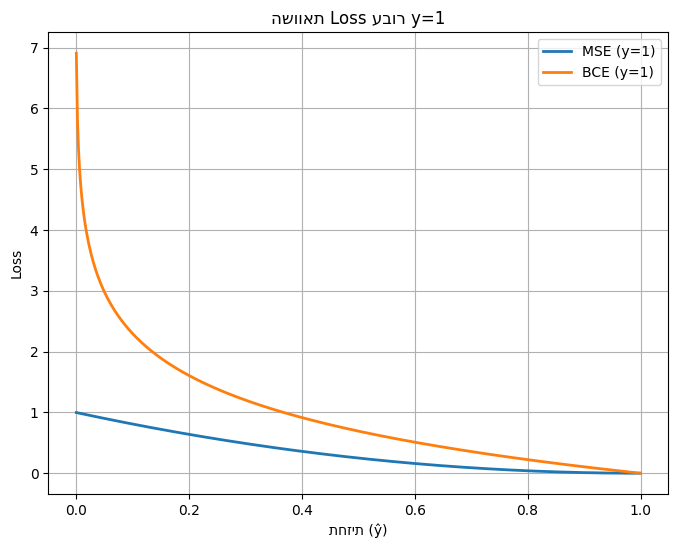

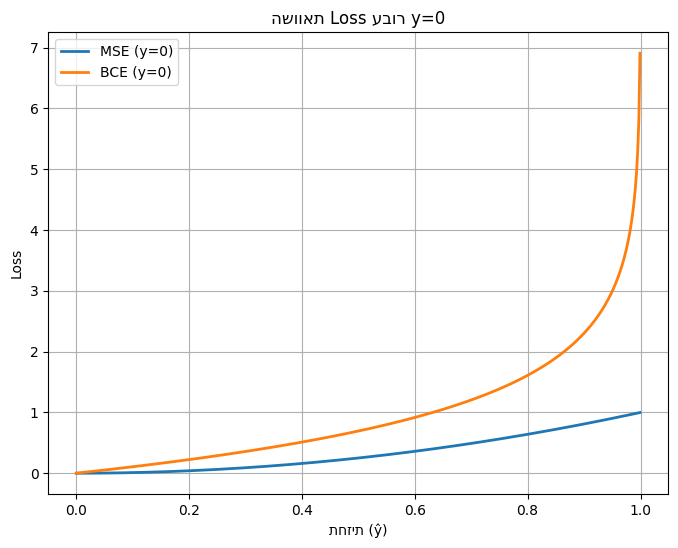

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# טווח תחזיות (למנוע log(0))
preds = np.linspace(0.001, 0.999, 500)

# --- עבור y=1 ---
y1 = 1
mse1 = (y1 - preds)**2
bce1 = -(y1*np.log(preds) + (1-y1)*np.log(1-preds))

plt.figure(figsize=(8,6))
plt.plot(preds, mse1, label="MSE (y=1)", linewidth=2)
plt.plot(preds, bce1, label="BCE (y=1)", linewidth=2)
plt.title("השוואת Loss עבור y=1")
plt.xlabel("תחזית (ŷ)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- עבור y=0 ---
y0 = 0
mse0 = (y0 - preds)**2
bce0 = -(y0*np.log(preds) + (1-y0)*np.log(1-preds))
7
plt.figure(figsize=(8,6))
plt.plot(preds, mse0, label="MSE (y=0)", linewidth=2)
plt.plot(preds, bce0, label="BCE (y=0)", linewidth=2)
plt.title("השוואת Loss עבור y=0")
plt.xlabel("תחזית (ŷ)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

L=N1​i=1∑N​(ypred​(i)−ytrue​(i))

mse function loss

In [ ]:

import numpy as np

# תחזית מהמודל (softmax)
y_pred = np.array([0.7, 0.2, 0.1])   # הסתברויות לשלוש קטגוריות
# אמת (המילה הנכונה היא הקטגוריה השנייה)
y_true = np.array([0, 1, 0])

# ===== 1. MSE =====
mse_loss = np.mean((y_pred - y_true) ** 2)
mse_grad = 2 * (y_pred - y_true) / len(y_pred)   # נגזרת MSE לפי y_pred

# ===== 2. Cross Entropy =====
ce_loss = -np.sum(y_true * np.log(y_pred + 1e-9))
ce_grad = y_pred - y_true   # נגזרת Cross Entropy עם softmax

print("MSE Loss:", mse_loss)
print("MSE Gradient:", mse_grad)

print("\nCross Entropy Loss:", ce_loss)
print("Cross Entropy Gradient:", ce_grad)

MSE Loss: 0.38000000000000006
MSE Gradient: [ 0.46666667 -0.53333333  0.06666667]

Cross Entropy Loss: 1.6094379074341003
Cross Entropy Gradient: [ 0.7 -0.8  0.1]


ההבדל המהותי

MSE → מודד מרחק מספרי בין פלט לתשובה (מתאים לרגרסיה רציפה).

BCE → מודד "כמה גרועה" ההתפלגות החזויה מול האמת (מתאים לבינארי).

במילים אחרות:

ב־MSE המודל לומד "לקרב מספר למספר".

ב־BCE המודל לומד "להגדיל הסתברות נכונה ולהקטין הסתברות שגויה".

In [ ]:

import numpy as np

# פונקציית softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # יציבות מספרית
    return exp_z / np.sum(exp_z)

# חישוב Jacobian של softmax
def softmax_jacobian(z):
    s = softmax(z)
    jacobian = np.diag(s) - np.outer(s, s)
    return jacobian

# דוגמה: וקטור ציונים ל-3 מחלקות
z = np.array([2.0, 1.0, 0.1])
s = softmax(z)
J = softmax_jacobian(z)

s, J

(array([0.65900114, 0.24243297, 0.09856589]),
 array([[ 0.22471864, -0.1597636 , -0.06495503],
        [-0.1597636 ,  0.18365923, -0.02389562],
        [-0.06495503, -0.02389562,  0.08885066]]))

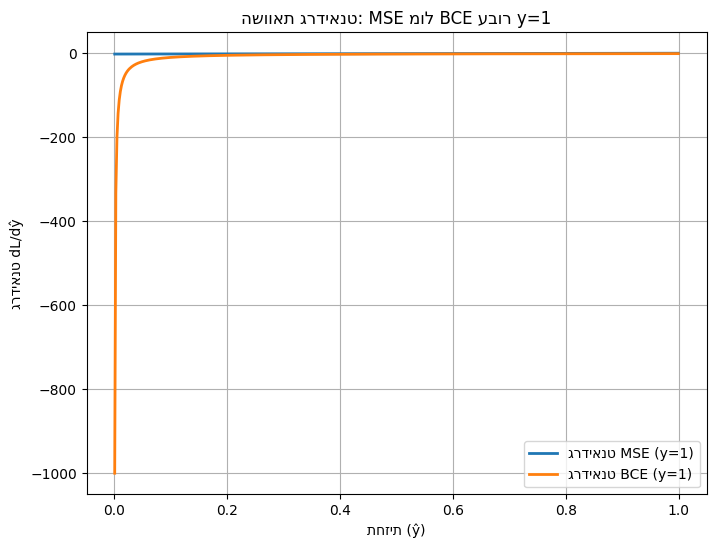

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# טווח תחזיות
preds = np.linspace(0.001, 0.999, 500)
y = 1
# --- גרדיאנט של MSE ---
# MSE = (y - p)^2 -> dL/dp = -2(y - p)
grad_mse = -2 * (y - preds)
# --- גרדיאנט של BCE ---
# BCE = -(y*log(p) + (1-y)log(1-p))
# עבור y=1 -> dL/dp = -1/p
grad_bce = -1 / preds
# ציור
plt.figure(figsize=(8,6))
plt.plot(preds, grad_mse, label="גרדיאנט MSE (y=1)", linewidth=2)
plt.plot(preds, grad_bce, label="גרדיאנט BCE (y=1)", linewidth=2)
plt.title("השוואת גרדיאנט: MSE מול BCE עבור y=1")
plt.xlabel("תחזית (ŷ)")
plt.ylabel("גרדיאנט dL/dŷ")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# טווח בין 0 ל-1
x = np.linspace(0.001, 0.999, 500)
y = -np.log(x)

# ציור
plt.figure(figsize=(8,6))
plt.plot(x, y, linewidth=2, color='purple')
plt.title("הפונקציה -log(x) על תחום (0,1)")
plt.xlabel("הסתברות חזויה (x)")
plt.ylabel("ענישה -log(x)")
plt.grid(True)
plt.show()


המעריכי "מנפח" מספרים → כל עלייה קטנה ב־xxx בצד החיובי יוצרת קפיצה גדולה.



הלוגריתם "דוחס" מספרים → לוקח מספרים גדולים ומחזיר אותם לסקאלה קטנה.

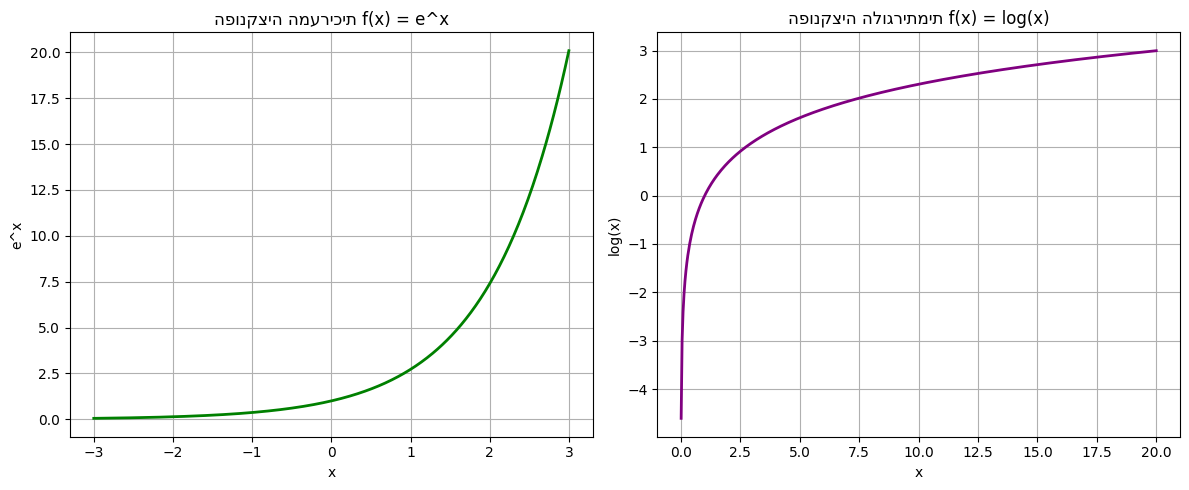

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# טווח ערכים
x_exp = np.linspace(-3, 3, 500)   # עבור exp
y_exp = np.exp(x_exp)

x_log = np.linspace(0.01, 20, 500) # עבור log (x>0)
y_log = np.log(x_log)

# ציור exp
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_exp, y_exp, color='green', linewidth=2)
plt.title("הפונקציה המעריכית f(x) = e^x")
plt.xlabel("x")
plt.ylabel("e^x")
plt.grid(True)

# ציור log
plt.subplot(1,2,2)
plt.plot(x_log, y_log, color='purple', linewidth=2)
plt.title("הפונקציה הלוגריתמית f(x) = log(x)")
plt.xlabel("x")
plt.ylabel("log(x)")
plt.grid(True)

plt.tight_layout()
plt.show()

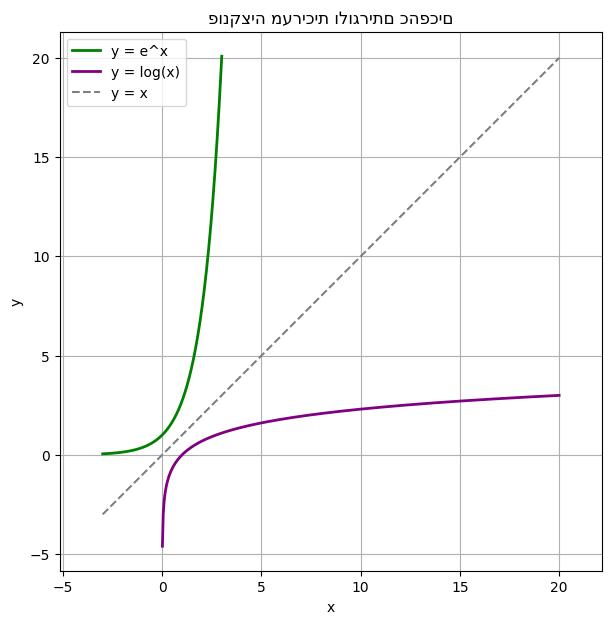

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# טווח עבור exp
x = np.linspace(-3, 3, 500)
y_exp = np.exp(x)

# טווח עבור log
x_log = np.linspace(0.01, 20, 500)
y_log = np.log(x_log)

# ציור exp ו-log באותו גרף
plt.figure(figsize=(7,7))
plt.plot(x, y_exp, label="y = e^x", color="green", linewidth=2)
plt.plot(x_log, y_log, label="y = log(x)", color="purple", linewidth=2)
plt.plot([-3,20], [-3,20], "--", color="gray", label="y = x")  # קו זהות

plt.title("פונקציה מעריכית ולוגריתם כהפכים")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

cce

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# טווח הסתברויות לקטגוריה הנכונה (מ-0 עד 1)
p_correct = np.linspace(0.001, 0.999, 500)

# CCE Loss = -log(p_correct)
cce = -np.log(p_correct)

# ציור הגרף
plt.figure(figsize=(8,6))
plt.plot(p_correct, cce, linewidth=2, color="purple")
plt.title("CCE Loss כפונקציה של ההסתברות לקטגוריה הנכונה")
plt.xlabel("הסתברות לקטגוריה הנכונה (ŷ)")
plt.ylabel("CCE Loss = -log(ŷ)")
plt.grid(True)
plt.show()


מעריכי "לוקח קטן → הופך לגדול" (אם חיובי).



לוגריתם "לוקח גדול → מחזיר לקטן".



ואם הולכים קרוב ל־0:



מעריכי → מתקרב ל־0 (אבל אף פעם לא 0).



לוגריתם → עף למינוס אינסוף.






💡 אפשר לחשוב ככה:



exe^xex = מאיץ מספרים.



log⁡(x)\log(x)log(x) = מאט מספרים.

2 דוגמאות אחד bce אחד mse

mse

In [ ]:

import numpy as np

# נתוני אמת (שער AND)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# פרמטרים
np.random.seed(0)
W = np.random.randn(2,1)
b = np.zeros((1,))
lr = 0.1

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# אימון
for epoch in range(1000):
    z = X @ W + b
    y_hat = sigmoid(z)

    # Loss (MSE)
    loss = np.mean((y - y_hat)**2)

    # נגזרות
    dL_dy = -2*(y - y_hat) / len(y)
    dy_dz = y_hat * (1 - y_hat)
    dz_dW = X
    dz_db = 1

    dL_dz = dL_dy * dy_dz
    dW = dz_dW.T @ dL_dz
    db = np.sum(dL_dz)

    # עדכון
    W -= lr * dW
    b -= lr * db

print("MSE Loss סופי:", loss)
print("תחזיות:", sigmoid(X @ W + b).round(3))

MSE Loss סופי: 0.05217313947314588
תחזיות: [[0.042]
 [0.236]
 [0.247]
 [0.7  ]]


bce

In [ ]:

import numpy as np

# נתוני אמת (שער AND)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# פרמטרים
np.random.seed(0)
W = np.random.randn(2,1)
b = np.zeros((1,))
lr = 0.1

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# אימון
for epoch in range(1000):
    z = X @ W + b
    y_hat = sigmoid(z)

    # Loss (BCE)
    loss = -np.mean(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))

    # נגזרות BCE עם Sigmoid
    dW = X.T @ (y_hat - y) / len(y)
    db = np.sum(y_hat - y) / len(y)

    # עדכון
    W -= lr * dW
    b -= lr * db

print("BCE Loss סופי:", loss)
print("תחזיות:", sigmoid(X @ W + b).round(3))

BCE Loss סופי: 0.13504492653728517
תחזיות: [[0.007]
 [0.141]
 [0.143]
 [0.798]]


softmax simple

In [ ]:

import numpy as np

def softmax(x):
    # טריק מספרי: מחסרים את הערך המקסימלי כדי להימנע מהצפות
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

# דוגמה
logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)
#לוגיטים הם הפלט הגולמי של הרשת הנוירונית לפני הפעלת פונקציית אקטיבציה
print("לוגיטים:", logits)
print("הסתברויות:", probs)
print("סכום:", np.sum(probs))

לוגיטים: [2.  1.  0.1]
הסתברויות: [0.65900114 0.24243297 0.09856589]
סכום: 1.0


In [ ]:

import numpy as np

# פונקציה: f(x, y) = [x+y, x*y]
def f(vec):
    x, y = vec
    return np.array([x + y, x * y])

# Jacobian חישוב ידני עם נגזרות סופיות (approx)
def jacobian(func, vec, eps=1e-6):
    n = len(vec)
    m = len(func(vec))
    J = np.zeros((m, n))
    for j in range(n):
        e = np.zeros(n)
        e[j] = eps
        J[:, j] = (func(vec + e) - func(vec - e)) / (2 * eps)
    return J

# דוגמה מספרית
point = np.array([2.0, 3.0])
J = jacobian(f, point)

J

array([[1., 1.],
       [3., 2.]])

Jacobian

טבלה:
 מה שיניתי  כמה שיניתי  ערך חדש של f1  שינוי בפלט
שינוי ב-x         1.0          12.00        5.00
שינוי ב-x         0.5           9.25        2.25
שינוי ב-x         0.1           7.41        0.41
שינוי ב-x        -0.1           6.61       -0.39
שינוי ב-x        -0.5           5.25       -1.75
שינוי ב-x        -1.0           4.00       -3.00
שינוי ב-y         1.0           8.00        1.00
שינוי ב-y         0.5           7.50        0.50
שינוי ב-y         0.1           7.10        0.10
שינוי ב-y        -0.1           6.90       -0.10
שינוי ב-y        -0.5           6.50       -0.50
שינוי ב-y        -1.0           6.00       -1.00


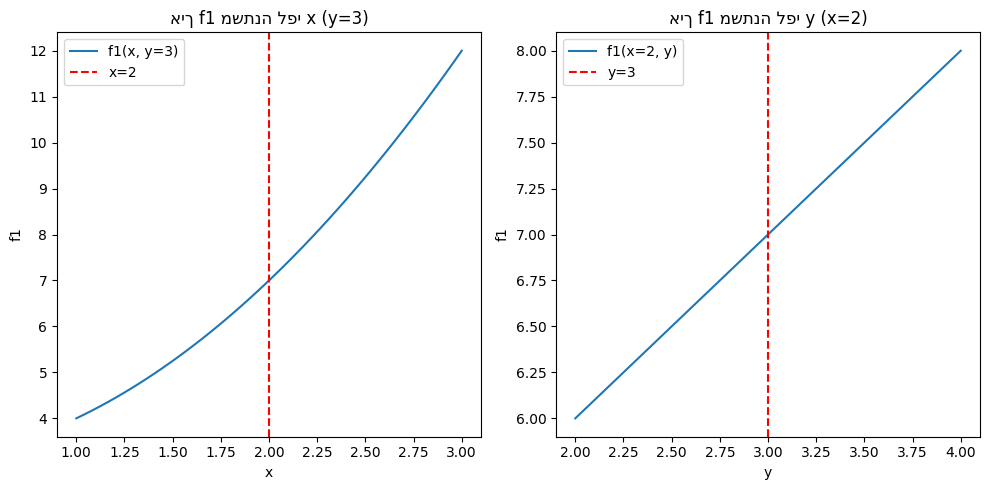

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# הפונקציה f1(x,y) = x^2 + y
def f1(x, y):
    return x**2 + y

# נקודת בסיס
x0, y0 = 2, 3
base_value = f1(x0, y0)

# נבדוק שינויים קטנים
deltas = [1, 0.5, 0.1, -0.1, -0.5, -1]
results = []

# שינויים ב-x
for dx in deltas:
    val = f1(x0 + dx, y0)
    change = val - base_value
    results.append(("שינוי ב-x", dx, val, change))

# שינויים ב-y
for dy in deltas:
    val = f1(x0, y0 + dy)
    change = val - base_value
    results.append(("שינוי ב-y", dy, val, change))

# טבלה
df = pd.DataFrame(results, columns=["מה שיניתי", "כמה שיניתי", "ערך חדש של f1", "שינוי בפלט"])
print("טבלה:\n", df.to_string(index=False))

# ציור גרף
x_vals = np.linspace(1, 3, 50)   # x נע סביב 2
y_vals = np.linspace(2, 4, 50)   # y נע סביב 3

fx = [f1(x, y0) for x in x_vals]
fy = [f1(x0, y) for y in y_vals]

plt.figure(figsize=(10,5))

# גרף שינוי לפי x
plt.subplot(1,2,1)
plt.plot(x_vals, fx, label="f1(x, y=3)")
plt.axvline(x=2, color='red', linestyle='--', label="x=2")
plt.xlabel("x")
plt.ylabel("f1")
plt.title("איך f1 משתנה לפי x (y=3)")
plt.legend()

# גרף שינוי לפי y
plt.subplot(1,2,2)
plt.plot(y_vals, fy, label="f1(x=2, y)")
plt.axvline(x=3, color='red', linestyle='--', label="y=3")
plt.xlabel("y")
plt.ylabel("f1")
plt.title("איך f1 משתנה לפי y (x=2)")
plt.legend()

plt.tight_layout()
plt.show()

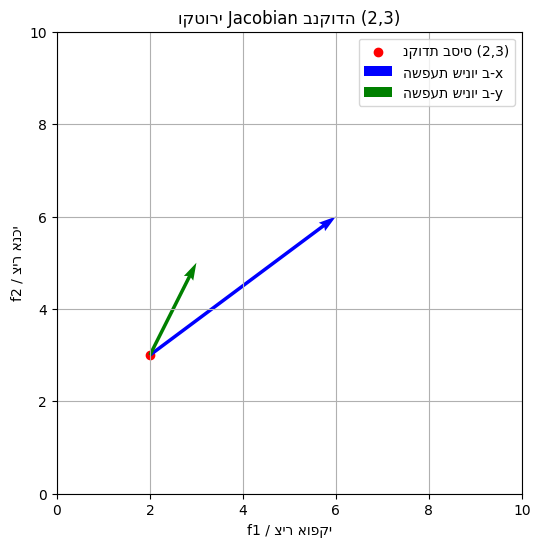

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# הפונקציות שלנו
#def f1(x,y):
#    return x**2 + y

#def f2(x,y):
#    return x*y

# נקודה
x0, y0 = 2, 3

# Jacobian בנקודה (2,3):
# J = [[4,1],
#      [3,2]]
J = np.array([[4,1],
              [3,2]])

# וקטורים (העמודות של ה-Jacobian)
dx_vec = J[:,0]  # תגובה לשינוי ב-x
dy_vec = J[:,1]  # תגובה לשינוי ב-y

# ציור
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# הנקודה שלנו (x=2,y=3) מוצגת כמרכז
plt.scatter([x0], [y0], color="red", label="נקודת בסיס (2,3)")

# חץ לשינוי ב-x
plt.quiver(x0, y0, dx_vec[0], dx_vec[1], angles='xy', scale_units='xy', scale=1, color="blue", label="השפעת שינוי ב-x")

# חץ לשינוי ב-y
plt.quiver(x0, y0, dy_vec[0], dy_vec[1], angles='xy', scale_units='xy', scale=1, color="green", label="השפעת שינוי ב-y")

plt.xlim(0,10)
plt.ylim(0,10)
plt.xlabel("f1 / ציר אופקי")
plt.ylabel("f2 / ציר אנכי")
plt.legend()
plt.title("וקטורי Jacobian בנקודה (2,3)")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# הפונקציה שלנו
def f(x, y):
    return np.array([x**2 + y, x*y])

# Jacobian ידני לפונקציה f
def jacobian(x, y):
    return np.array([
        [2*x, 1],
        [y,   x]
    ])

# נקודת בסיס
x0, y0 = 2.0, 3.0
f_base = f(x0, y0)
J = jacobian(x0, y0)

print("פלט הפונקציה f(2,3):", f_base)
print("Jacobian בנקודה (2,3):\n", J)

# שינוי קטן בקלט
dx, dy = 0.1, 0.0
delta_input = np.array([dx, dy])

# שינוי צפוי לפי Jacobian
delta_f_approx = J.dot(delta_input)

# שינוי אמיתי לפי חישוב ישיר
f_new = f(x0+dx, y0+dy)
delta_f_true = f_new - f_base

print("\nשינוי בקלט: dx=0.1, dy=0")
print("שינוי צפוי לפי Jacobian:", delta_f_approx)
print("שינוי אמיתי בפועל:", delta_f_true)

פלט הפונקציה f(2,3): [7. 6.]
Jacobian בנקודה (2,3):
 [[4. 1.]
 [3. 2.]]

שינוי בקלט: dx=0.1, dy=0
שינוי צפוי לפי Jacobian: [0.4 0.3]
שינוי אמיתי בפועל: [0.41 0.3 ]


softmax with cce

In [ ]:

import numpy as np

# פונקציית Softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # יציבות נומרית
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# פונקציית Loss: Categorical Cross-Entropy
def categorical_cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

# יצירת דאטה פשוט (4 דוגמאות, 3 מחלקות)
X = np.array([
    [1, 0, 0],  # דוגמה ראשונה
    [0, 1, 0],  # שנייה
    [0, 0, 1],  # שלישית
    [1, 1, 0],  # רביעית
])

y_true = np.array([
    [1, 0, 0],  # המחלקה הנכונה לדוגמה 1
    [0, 1, 0],  # לדוגמה 2
    [0, 0, 1],  # לדוגמה 3
    [1, 0, 0],  # לדוגמה 4
])

# פרמטרים התחלתיים (משקולות ואפסים)
np.random.seed(0)
W = np.random.randn(3, 3) * 0.1
b = np.zeros((1, 3))

# קצב למידה
lr = 0.1

# אימון
for epoch in range(1001):
    # צעד קדימה
    logits = X.dot(W) + b
    y_pred = softmax(logits)

    # חישוב הפסד
    loss = categorical_cross_entropy(y_true, y_pred)

    # חישוב גרדיאנט
    grad_logits = (y_pred - y_true) / X.shape[0]
    dW = X.T.dot(grad_logits)
    db = np.sum(grad_logits, axis=0, keepdims=True)

    # עדכון פרמטרים
    W -= lr * dW
    b -= lr * db

    # הדפסה כל 200 אפוקים
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 1.0272
Epoch 200, Loss: 0.1590
Epoch 400, Loss: 0.0805
Epoch 600, Loss: 0.0535
Epoch 800, Loss: 0.0400
Epoch 1000, Loss: 0.0319


mse vs bce

In [ ]:
# נריץ מחדש אחרי reset של הסביבה
import numpy as np
import matplotlib.pyplot as plt
# ערכי תחזית אפשריים (0 עד 1)
y_hat = np.linspace(0.001, 0.999, 200)
# אמת - במקרה הזה נניח y=1 (כלומר תשובה נכונה היא 1)
y = 1
# חישוב MSE ו-BCE
mse_loss = (y - y_hat) ** 2
bce_loss = - (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
# ציור גרפים
plt.figure(figsize=(8,5))
plt.plot(y_hat, mse_loss, label="MSE Loss", color="blue")
plt.plot(y_hat, bce_loss, label="BCE Loss (Log Loss)", color="red")
plt.title("השוואת פונקציות עלות: MSE vs BCE (y=1)")
plt.xlabel("חיזוי (ŷ)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

y=0

In [ ]:
# ערכי תחזית אפשריים (0 עד 1)
y_hat = np.linspace(0.001, 0.999, 200)
# אמת - הפעם y=0 (כלומר תשובה נכונה היא 0)
y = 0
# חישוב MSE ו-BCE
mse_loss_0 = (y - y_hat) ** 2
bce_loss_0 = - (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
# ציור גרפים
plt.figure(figsize=(8,5))
plt.plot(y_hat, mse_loss_0, label="MSE Loss (y=0)", color="blue")
plt.plot(y_hat, bce_loss_0, label="BCE Loss (y=0)", color="red")
plt.title("השוואת פונקציות עלות: MSE vs BCE (y=0)")
plt.xlabel("חיזוי (ŷ)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

jacobian

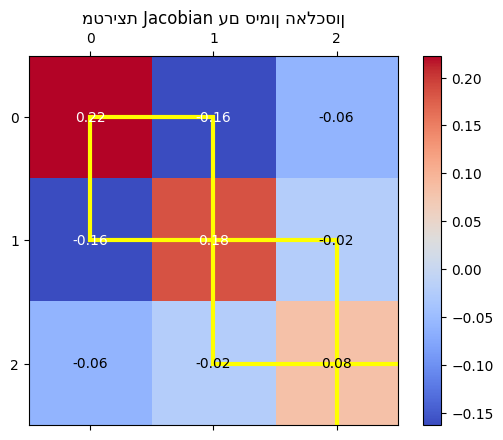

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# דוגמה מטריצה 3x3
A = np.array([
    [0.223, -0.163, -0.060],
    [-0.163, 0.185, -0.022],
    [-0.060, -0.022, 0.082]
])

fig, ax = plt.subplots()
cax = ax.matshow(A, cmap="coolwarm")

# ציור ערכים על המטריצה
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        text_color = "white" if abs(A[i, j]) > 0.1 else "black"
        ax.text(j, i, f"{A[i,j]:.2f}", va="center", ha="center", color=text_color)

# סימון האלכסון בצבע
for i in range(A.shape[0]):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="yellow", linewidth=3))

plt.title("מטריצת Jacobian עם סימון האלכסון")
plt.colorbar(cax)
plt.show()